In [1]:
# classifires

from scipy.stats import pearsonr
from sklearn.svm import LinearSVC, SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.datasets import make_classification
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import KFold, LeaveOneOut, cross_val_score
from sklearn.tree import DecisionTreeClassifier, ExtraTreeClassifier
from sklearn.gaussian_process import GaussianProcessClassifier
from sklearn.linear_model import LogisticRegression, RidgeClassifier, SGDClassifier, PassiveAggressiveClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.ensemble import GradientBoostingClassifier, AdaBoostClassifier, BaggingClassifier, RandomForestClassifier, ExtraTreesClassifier
import joblib

In [2]:
# general purpose libraries

import time
from datetime import datetime
import numpy as np
from numpy import mean, isnan, asarray, polyfit
import pandas as pd
# import seaborn as sns
from sklearn import metrics
from matplotlib import pyplot
import matplotlib.pyplot as plt
from sklearn.utils import shuffle
from sklearn.decomposition import PCA
from mpl_toolkits.mplot3d import Axes3D
from sklearn.preprocessing import LabelBinarizer, label_binarize
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder
from sklearn.model_selection import KFold, StratifiedKFold, StratifiedShuffleSplit, cross_val_score, LeaveOneOut, cross_validate, cross_val_predict, GroupKFold
from sklearn.metrics import classification_report, roc_curve, auc, RocCurveDisplay, roc_auc_score, log_loss
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, f1_score, precision_score, recall_score, make_scorer
from sklearn.ensemble import VotingClassifier, StackingClassifier
from matplotlib.font_manager import FontProperties
from collections import Counter
# import rasterio as rio
#from imblearn.over_sampling import ADASYN

# Histogram display
import matplotlib.pyplot as plt
# import earthpy.plot as ep

In [4]:
path_BSMOTE_data = r"..\..\Data\5.Borderline_SMOTE\\"

In [5]:
print("Started...")
start_time = datetime.now()
num_samples = 1000000

tomato_healthy = pd.read_excel(path_BSMOTE_data + "tomato_healthy.xlsx", sheet_name='Sheet1', engine='openpyxl')[:num_samples]
tomato_unhealthy = pd.read_excel(path_BSMOTE_data + "tomato_unhealthy.xlsx", sheet_name='Sheet1', engine='openpyxl')[:num_samples]
capsicum = pd.read_excel(path_BSMOTE_data + "capsicum.xlsx", sheet_name='Sheet1', engine='openpyxl').sample(frac = 1)[:num_samples]
chilli = pd.read_excel(path_BSMOTE_data + "chilli.xlsx", sheet_name='Sheet1', engine='openpyxl').sample(frac = 1)[:num_samples]
potato = pd.read_excel(path_BSMOTE_data + "potato.xlsx", sheet_name='Sheet1', engine='openpyxl')[:num_samples]                        
mulberry = pd.read_excel(path_BSMOTE_data + "mulberry.xlsx", sheet_name='Sheet1', engine='openpyxl').sample(frac = 1)[:num_samples]

end_time = datetime.now()
print('Data loading time is:> {}'.format(end_time - start_time))

# Data shapes
print("data_tomato_healthy:", tomato_healthy.shape)
print("data_tomato_unhealthy:", tomato_unhealthy.shape)
print("data_capsicum:", capsicum.shape)
print("data_chilli:", chilli.shape)
print("data_potato:", potato.shape)
print("data_mulberry:", mulberry.shape)

Started...
Data loading time is:> 0:04:26.455169
data_tomato_healthy: (2000, 944)
data_tomato_unhealthy: (2000, 944)
data_capsicum: (2000, 944)
data_chilli: (2000, 944)
data_potato: (2000, 944)
data_mulberry: (2000, 944)


In [6]:
# Shuffleing

tomato_healthy = tomato_healthy.sample(frac = 1)
tomato_healthy = tomato_healthy.sample(frac = 1)

tomato_unhealthy = tomato_unhealthy.sample(frac = 1)
tomato_unhealthy = tomato_unhealthy.sample(frac = 1)

chilli = chilli.sample(frac = 1)
chilli = chilli.sample(frac = 1)

capsicum = capsicum.sample(frac = 1)
capsicum = capsicum.sample(frac = 1)

potato = potato.sample(frac = 1)
potato = potato.sample(frac = 1)

mulberry = mulberry.sample(frac = 1)
mulberry = mulberry.sample(frac = 1)

In [6]:
# # Selecting first 1000 samples
# data_tomato_unhealthy = data_tomato_unhealthy.iloc[:1000]
# data_chilli = data_chilli.iloc[:1000]
# data_capsicum = data_capsicum.iloc[:1000]
# data_mulberry = data_mulberry.iloc[:1000]
# data_potato = data_potato.iloc[:1000]

# print("tomato_healthy:", data_tomato_healthy.shape)
# print("tomato_unhealthy:", data_tomato_unhealthy.shape)
# print("data_potato:", data_potato.shape)
# print("chilli:", data_chilli.shape)
# print("capsicum:", data_capsicum.shape)
# print("mulberry:", data_mulberry.shape)

In [7]:
# merging all dataframes into one 
data = pd.concat([tomato_healthy,capsicum,tomato_unhealthy,potato,chilli,mulberry], ignore_index=True, axis=0)
print("data:", data.shape)

data: (12000, 944)


In [8]:
df_final = data.copy() 
df_final = df_final.sample(frac = 1)
df_final = df_final.sample(frac = 1)
df_final

,label,400,401,402,403,404,405,406,407,408,...,1333,1334,1335,1336,1337,1338,1339,1340,1341,1342
7911,potato,0.092311,0.095885,0.093952,0.088418,0.089825,0.095022,0.097683,0.094250,0.091442,...,0.569670,0.566254,0.564430,0.562770,0.560307,0.560139,0.557821,0.550737,0.547851,0.548539
4774,tomato_unhealthy,0.035419,0.036928,0.039550,0.040474,0.040096,0.040917,0.042490,0.043468,0.042247,...,0.375625,0.373578,0.371899,0.369844,0.368397,0.367882,0.366996,0.365579,0.365008,0.366010
11987,mulberry,0.227042,0.228431,0.227767,0.222792,0.220508,0.219336,0.219953,0.221969,0.219135,...,0.675834,0.672668,0.670059,0.666652,0.664946,0.664790,0.664539,0.665806,0.665826,0.665601
6292,potato,0.097045,0.098817,0.096581,0.093259,0.084801,0.087816,0.094302,0.093026,0.086123,...,0.517687,0.512338,0.509976,0.513352,0.510129,0.501998,0.498998,0.494352,0.492822,0.500732
9629,chilli,0.160156,0.156788,0.159167,0.166032,0.163158,0.158514,0.157161,0.160765,0.161332,...,0.595382,0.593735,0.590514,0.585825,0.583049,0.579431,0.577709,0.579004,0.578591,0.578015
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3780,capsicum,0.104456,0.103464,0.102885,0.103629,0.103222,0.102977,0.101619,0.099229,0.104283,...,0.483548,0.480903,0.478717,0.475899,0.474608,0.474886,0.473689,0.472270,0.471412,0.469128
5912,tomato_unhealthy,0.089444,0.090144,0.092190,0.092939,0.092692,0.092649,0.092682,0.092709,0.092330,...,0.529303,0.525360,0.522485,0.519158,0.517301,0.517367,0.515810,0.514222,0.512463,0.508509
10978,mulberry,0.068687,0.069656,0.067288,0.065655,0.067596,0.068610,0.068272,0.067335,0.066224,...,0.531945,0.528686,0.526451,0.523096,0.521381,0.521973,0.519959,0.516006,0.514222,0.512432
9107,chilli,0.111394,0.107417,0.106244,0.110111,0.106947,0.102515,0.102061,0.107091,0.105375,...,0.547271,0.543950,0.541952,0.539644,0.538642,0.539987,0.539189,0.537317,0.536279,0.533508


In [9]:
# Removing odds
df_final = df_final[~df_final.isin([np.nan, np.inf, -np.inf]).any(axis = 1)]

In [10]:
# visulization class distribution

def freq_visualize(df_final, title):
    print(df_final['label'].value_counts())
    labels = df_final['label'].values
    counter = Counter(labels) # counter object
    counter = dict(sorted(counter.items())) # converting counter obj. into dictionary
    x = list(counter.keys())
    y = list(counter.values())
    plt.rcParams.update({'font.size':8})
    fig = plt.figure(num=None, figsize=(10, 4), dpi=200, facecolor='w', edgecolor='red')
    plt.barh(x, y)
    plt.xlim(0, 3000)
    plt.ylabel("Labels", weight ='bold')
    plt.xlabel("Frequencies", weight ='bold')
    plt.title(title)
    plt.show()

chilli              2000
tomato_healthy      2000
potato              2000
mulberry            2000
capsicum            2000
tomato_unhealthy    2000
Name: label, dtype: int64


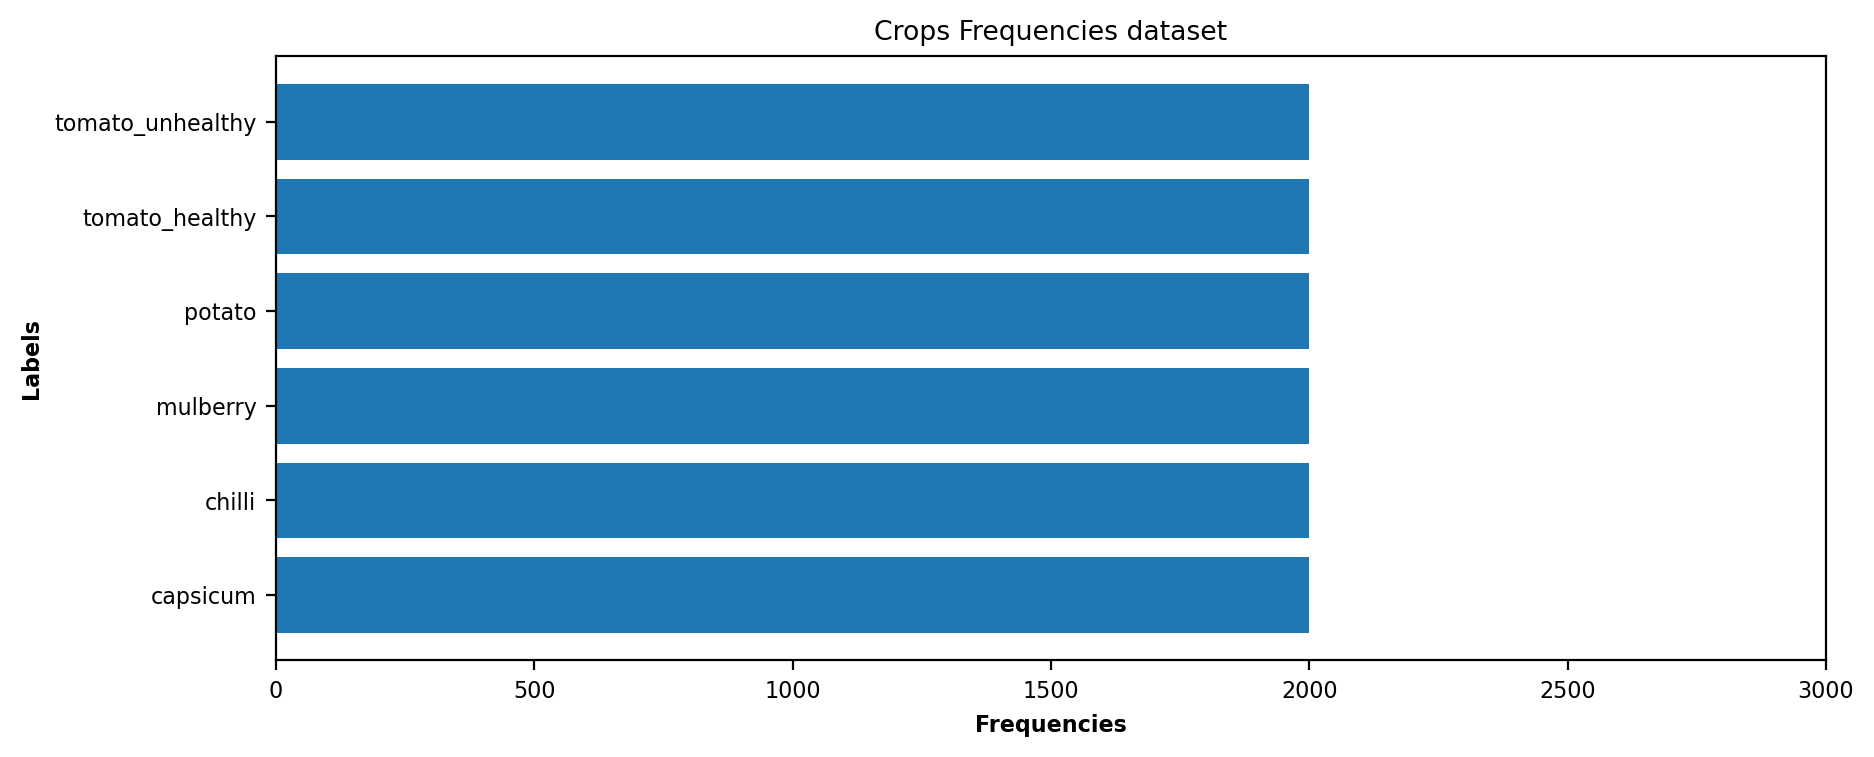

In [11]:
# calling the visualization function
freq_visualize(df_final, title="Crops Frequencies dataset")

In [12]:
# preparing trauing and testing datasets and label encoding
from sklearn import preprocessing

features = df_final.columns.difference(['label'])
X = df_final[features].values
y = df_final['label'].values

label_encoder = preprocessing.LabelEncoder()
y = label_encoder.fit_transform(y)

print(type(X),"X:", X.shape)
print(type(y),"y:", y.shape)
print('\nunique values:\n', np.unique(y))

<class 'numpy.ndarray'> X: (12000, 943)
<class 'numpy.ndarray'> y: (12000,)

unique values:
 [0 1 2 3 4 5]


In [13]:
# label encoded class names
le = label_encoder
le_name_mapping = dict(zip(le.classes_, le.transform(le.classes_)))
print(le_name_mapping)

{'capsicum': 0, 'chilli': 1, 'mulberry': 2, 'potato': 3, 'tomato_healthy': 4, 'tomato_unhealthy': 5}


In [14]:
# data splitting
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 100, stratify=y)

print(type(X_train), X_train.shape)
print(type(y_train), y_train.shape)
print(type(X_test), X_test.shape)
print(type(y_test), y_test.shape)

<class 'numpy.ndarray'> (8400, 943)
<class 'numpy.ndarray'> (8400,)
<class 'numpy.ndarray'> (3600, 943)
<class 'numpy.ndarray'> (3600,)


## Creating Cutom Ensemble model

In [17]:
# Listing the all models | commented some models due to predict_proba unavailability
def get_models():
    models = list()
    models.append(LogisticRegression(max_iter=1000))
    models.append(SGDClassifier(loss='log'))  # Set loss='log' for predict_proba
    models.append(GaussianNB())
    models.append(QuadraticDiscriminantAnalysis(reg_param=0.1))
    models.append(SVC(C=100, kernel='rbf', degree=3, gamma='auto', coef0=0.0, shrinking=True, probability=True, tol=0.001, cache_size=200, class_weight=None, verbose=0, max_iter=-1, decision_function_shape="ovr", random_state = 45)) # this
#     models.append(LinearSVC(dual=False)) # this
#     models.append(KNeighborsClassifier(n_neighbors=6))
#     models.append(RidgeClassifier()) # this
#     models.append(DecisionTreeClassifier())
#     models.append(AdaBoostClassifier(n_estimators=100, learning_rate=1))
#     models.append(RandomForestClassifier())
#     models.append(GradientBoostingClassifier())
    return models

# Function to create and train ensemble models
def create_ensemble(ensemble_type='soft_voting'): # soft_voting, stacking
    base_models = get_models()
    estimators = [(model.__class__.__name__.lower(), model) for model in base_models]
    
    if ensemble_type == 'soft_voting':
        # Create soft voting ensemble
        ensemble = VotingClassifier(estimators=estimators, voting='soft')
        print("Soft_voting is selected")
    elif ensemble_type == 'stacking':
        # Create stacking ensemble with LogisticRegression as meta-learner
        meta_learner = LogisticRegression(max_iter=1000)
        ensemble = StackingClassifier(estimators=estimators, final_estimator=meta_learner, cv=5)
        print("Stacking is selected")
    else:
        raise ValueError("ensemble_type must be 'soft_voting' or 'stacking'")
    return ensemble

In [18]:
# model training
model = create_ensemble(ensemble_type='soft_voting')
# -------------Start the training--------
tic = time.time()
model.fit(X_train, y_train)
toc = time.time()

training_time = time.strftime("%H:%M:%S", time.gmtime(toc-tic))
print("training time is {} in Hour:Minute:Seconds".format(training_time))



Soft_voting is selected


C:\Users\manoj\anaconda3\envs\tf\lib\site-packages\sklearn\linear_model\_logistic.py:765: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  extra_warning_msg=_LOGISTIC_SOLVER_CONVERGENCE_MSG)
C:\Users\manoj\anaconda3\envs\tf\lib\site-packages\sklearn\discriminant_analysis.py:808: UserWarning: Variables are collinear
  warnings.warn("Variables are collinear")


training time is 00:03:01 in Hour:Minute:Seconds


In [21]:
pred = model.predict(X_test)
# None, 'micro', 'macro', 'weighted', 'samples'
avg = 'macro'
accuracy = accuracy_score(y_test, pred)
precision = precision_score(y_test, pred, average=avg)
f1 = f1_score(y_test, pred, average=avg)
recall = recall_score(y_test, pred, average=avg)
mse = metrics.mean_squared_error(y_test, pred)
cnf = confusion_matrix(y_test, pred)
clf_refort = classification_report(y_test, pred)

results = {'CLF_Name': type(model).__name__, 'Accuracy': accuracy, 'Precision': precision, 'f1_score': f1, 'recall':recall, 'MSE':mse}
print(results, "\n")
print("Confusion Matrix: \n", cnf, "\n")
print("Classification Report: \n", clf_refort)


# {'CLF_Name': 'VotingClassifier', 'Accuracy': 0.9606679035250464, 'Precision': 0.948159551048283, 'f1_score': 0.9306256511339077, 'recall': 0.9199212557813636, 'MSE': 0.12356215213358071} 

# Confusion Matrix: 
#  [[1079    0    0    0    0    0]
#  [   0 1053    9    0    0    2]
#  [   0    0 1052    2    3    0]
#  [   4    0   24  785   25   33]
#  [   0   28   20   45  190   17]
#  [   0    0    0    0    0 1019]] 

# Classification Report: 
#                precision    recall  f1-score   support

#            0       1.00      1.00      1.00      1079
#            1       0.97      0.99      0.98      1064
#            2       0.95      1.00      0.97      1057
#            3       0.94      0.90      0.92       871
#            4       0.87      0.63      0.73       300
#            5       0.95      1.00      0.98      1019

#     accuracy                           0.96      5390
#    macro avg       0.95      0.92      0.93      5390
# weighted avg       0.96      0.96      0.96      5390

{'CLF_Name': 'VotingClassifier', 'Accuracy': 0.9405555555555556, 'Precision': 0.941783649289445, 'f1_score': 0.9398068826833397, 'recall': 0.9405555555555555, 'MSE': 0.17805555555555555} 

Confusion Matrix: 
 [[600   0   0   0   0   0]
 [  0 584  13   0   3   0]
 [ 18   0 568   0  14   0]
 [  9   7  55 492  37   0]
 [  3  17  11  16 542  11]
 [  0   0   0   0   0 600]] 

Classification Report: 
               precision    recall  f1-score   support

           0       0.95      1.00      0.98       600
           1       0.96      0.97      0.97       600
           2       0.88      0.95      0.91       600
           3       0.97      0.82      0.89       600
           4       0.91      0.90      0.91       600
           5       0.98      1.00      0.99       600

    accuracy                           0.94      3600
   macro avg       0.94      0.94      0.94      3600
weighted avg       0.94      0.94      0.94      3600



In [20]:
# saving the model
filename = '..\..\Models\Custom_ensemble_with_BSMOTE_Data_2.sav'
joblib.dump(model,filename)

['..\\..\\Models\\Custom_ensemble_with_BSMOTE_Data_2.sav']

# Testing in the same code file on 20% original data

In [22]:
path_real_data = r"..\..\Data\9.Split-data for revision\Test_20\\"

In [23]:
print("started...")
start_time = datetime.now()
num_samples = 1000000

data_tomato_healthy = pd.read_excel(path_real_data + "tomato_healthy.xlsx", sheet_name='Sheet1', engine='openpyxl')[:num_samples]
data_tomato_unhealthy = pd.read_excel(path_real_data + "tomato_Unhealthy.xlsx", sheet_name='Sheet1', engine='openpyxl')[:num_samples]
data_potato = pd.read_excel(path_real_data + "potato.xlsx", sheet_name='Sheet1', engine='openpyxl')[:num_samples]                  
data_chilli = pd.read_excel(path_real_data + "chilli.xlsx", sheet_name='Sheet1', engine='openpyxl').sample(frac = 1)[:num_samples]
data_capsicum = pd.read_excel(path_real_data + "capsicum.xlsx", sheet_name='Sheet1', engine='openpyxl').sample(frac = 1)[:num_samples]
data_mulberry = pd.read_excel(path_real_data + "mulberry.xlsx", sheet_name='Sheet1', engine='openpyxl').sample(frac = 1)[:num_samples]

end_time = datetime.now()
print('Data loading time is:> {}'.format(end_time - start_time))

print("tomato_healthy:", data_tomato_healthy.shape)
print("tomato_unhealthy:", data_tomato_unhealthy.shape)
print("data_potato:", data_potato.shape)
print("chilli:", data_chilli.shape)
print("capsicum:", data_capsicum.shape)
print("mulberry:", data_mulberry.shape)

started...
Data loading time is:> 0:00:21.626100
tomato_healthy: (534, 944)
tomato_unhealthy: (155, 944)
data_potato: (154, 944)
chilli: (25, 944)
capsicum: (15, 944)
mulberry: (30, 944)


In [24]:
# merging all dataframes into one 
data = pd.concat([data_tomato_healthy,data_capsicum,data_tomato_unhealthy, data_potato, data_chilli, data_mulberry], ignore_index=True, axis=0)

In [25]:
df_final = data.copy()
df_final = df_final.sample(frac = 1)
df_final = df_final.sample(frac = 1)

# Removing the corrupt data
df_final = df_final[~df_final.isin([np.nan, np.inf, -np.inf]).any(axis = 1)]
df_final

,label,400,401,402,403,404,405,406,407,408,...,1333,1334,1335,1336,1337,1338,1339,1340,1341,1342
274,tomato_healthy,0.105514,0.105559,0.107832,0.111278,0.110794,0.112217,0.113018,0.110530,0.109629,...,0.548280,0.544937,0.542435,0.539266,0.537157,0.536762,0.535468,0.533804,0.532186,0.530641
536,capsicum,0.123257,0.126942,0.129371,0.129548,0.123265,0.120814,0.122127,0.124220,0.125519,...,0.557344,0.556203,0.553707,0.550261,0.548465,0.547310,0.545404,0.543460,0.542913,0.542658
488,tomato_healthy,0.426725,0.425055,0.424378,0.425512,0.425354,0.425313,0.425102,0.424551,0.425683,...,0.240836,0.237347,0.233950,0.233232,0.230873,0.226693,0.224350,0.224052,0.221517,0.216874
900,mulberry,0.125327,0.128075,0.134678,0.137075,0.134277,0.132572,0.132572,0.133461,0.137050,...,0.494926,0.492132,0.489212,0.488778,0.486490,0.480179,0.477511,0.477995,0.476080,0.472660
295,tomato_healthy,0.082700,0.084000,0.083700,0.082100,0.084800,0.086500,0.087100,0.087700,0.088800,...,0.339104,0.335449,0.333115,0.333055,0.331267,0.327369,0.325773,0.326082,0.324789,0.323720
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
262,tomato_healthy,0.085400,0.084400,0.085977,0.088800,0.090300,0.089000,0.087300,0.087900,0.089500,...,0.620128,0.616547,0.613847,0.610680,0.608025,0.606765,0.605388,0.603672,0.602125,0.601840
907,mulberry,0.094375,0.095643,0.095304,0.094269,0.096635,0.093664,0.091045,0.094076,0.089567,...,0.586696,0.584301,0.581749,0.579434,0.576815,0.572529,0.571135,0.572516,0.571574,0.571097
96,tomato_healthy,0.072100,0.073800,0.075300,0.075300,0.080300,0.079900,0.078700,0.081500,0.078400,...,0.523687,0.523565,0.521912,0.519641,0.518430,0.517291,0.516088,0.515172,0.515140,0.516108
559,tomato_unhealthy,0.042500,0.041800,0.040500,0.040400,0.044200,0.046200,0.045434,0.043100,0.042600,...,0.260609,0.257411,0.255816,0.256216,0.254668,0.252099,0.250886,0.249262,0.248250,0.249098


tomato_healthy      534
tomato_unhealthy    155
potato              154
mulberry             30
chilli               25
capsicum             15
Name: label, dtype: int64


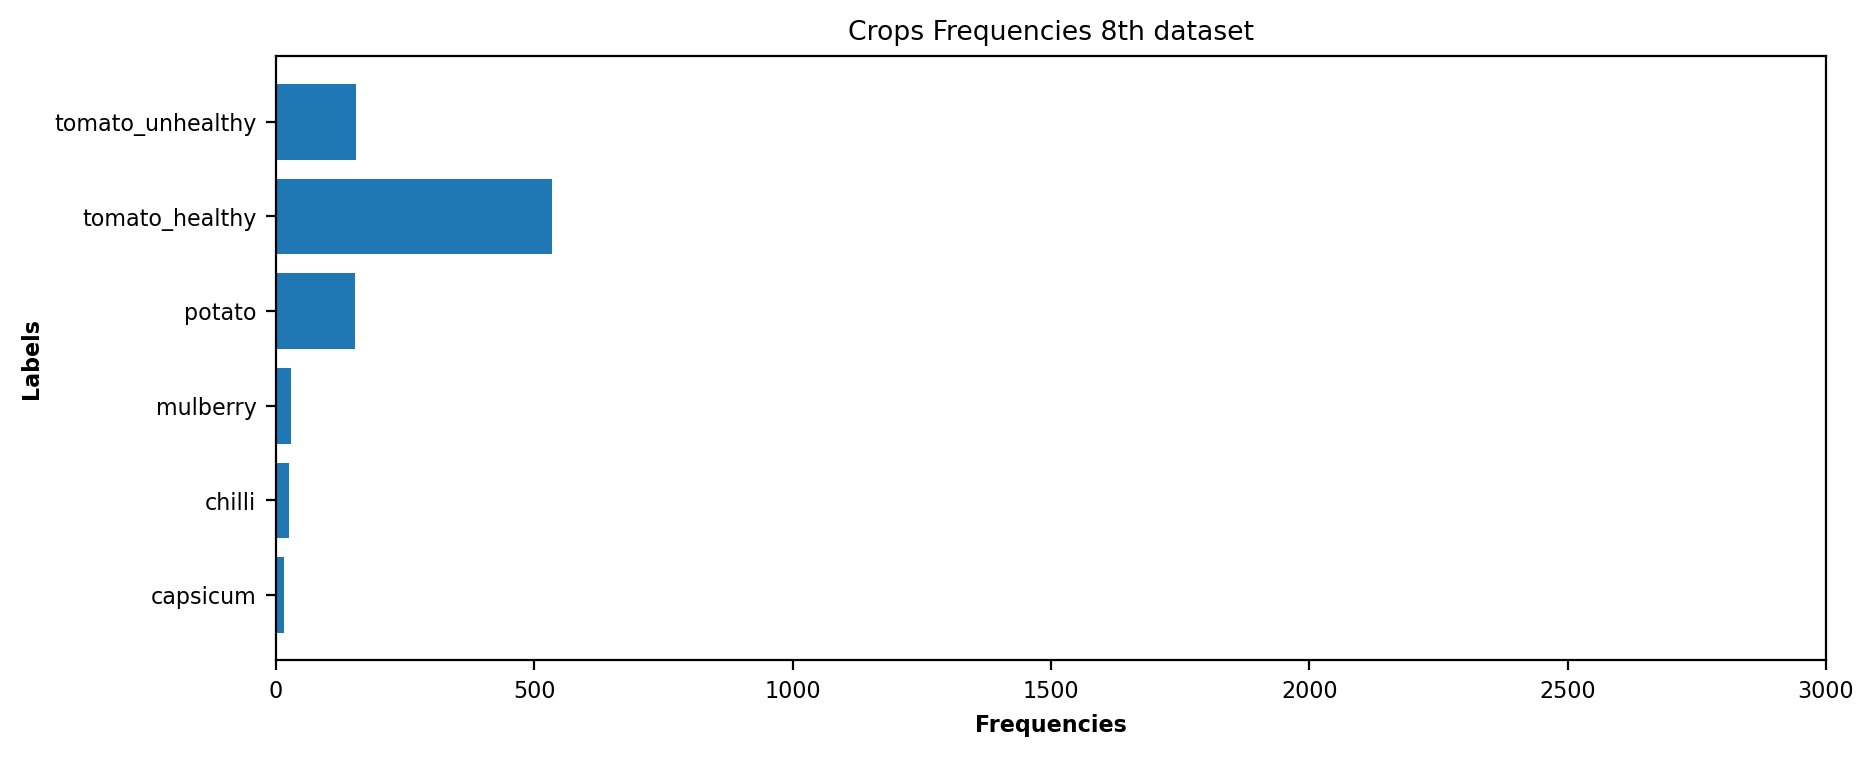

In [26]:
# calling the visualization function
freq_visualize(df_final, title="Crops Frequencies 8th dataset")

In [27]:
# preparing trauing and testing datasets and label encoding
from sklearn import preprocessing

features = df_final.columns.difference(['label'])
X = df_final[features].values
y = df_final['label'].values

label_encoder = preprocessing.LabelEncoder()
y = label_encoder.fit_transform(y)

print(type(X),"X:", X.shape)
print(type(y),"y:", y.shape)
print('\nunique values:\n', np.unique(y))

# label encoded class names
le = label_encoder
le_name_mapping = dict(zip(le.classes_, le.transform(le.classes_)))
print(le_name_mapping)

<class 'numpy.ndarray'> X: (913, 943)
<class 'numpy.ndarray'> y: (913,)

unique values:
 [0 1 2 3 4 5]
{'capsicum': 0, 'chilli': 1, 'mulberry': 2, 'potato': 3, 'tomato_healthy': 4, 'tomato_unhealthy': 5}


In [28]:
# Loading the model
# filename = r"..\..\Models\xxx.sav"
# model = joblib.load(filename)

pred = model.predict(X)
# None, 'micro', 'macro', 'weighted', 'samples'
avg = 'macro'
accuracy = accuracy_score(y, pred)
precision = precision_score(y, pred, average=avg)
f1 = f1_score(y, pred, average=avg)
recall = recall_score(y, pred, average=avg)
mse = metrics.mean_squared_error(y, pred)
cnf = confusion_matrix(y, pred)
clf_refort = classification_report(y, pred)

results = {'CLF_Name': type(model).__name__, 'Accuracy': "{:.2f}".format(accuracy), 'Precision': "{:.2f}".format(precision), 'F1_score': "{:.2f}".format(f1), 'Recall':"{:.2f}".format(recall), 'MSE':"{:.2f}".format(mse)}
print(results, "\n")
print("Confusion Matrix: \n", cnf, "\n")
print("Classification Report: \n", clf_refort)


# {'CLF_Name': 'VotingClassifier', 'Accuracy': '0.71', 'Precision': '0.62', 'F1_score': '0.67', 'Recall': '0.83', 'MSE': '1.02'} 

# Confusion Matrix: 
#  [[  64    8    0    0    0    3]
#  [   1  109    8    3    1    3]
#  [   0    0  144    3    3    0]
#  [   2    0   10  729    8   21]
#  [   6  234  181  479 1635  137]
#  [   0    0    0   75    0  199]] 

# Classification Report: 
#                precision    recall  f1-score   support

#            0       0.88      0.85      0.86        75
#            1       0.31      0.87      0.46       125
#            2       0.42      0.96      0.58       150
#            3       0.57      0.95      0.71       770
#            4       0.99      0.61      0.76      2672
#            5       0.55      0.73      0.62       274

#     accuracy                           0.71      4066
#    macro avg       0.62      0.83      0.67      4066
# weighted avg       0.84      0.71      0.73      4066

{'CLF_Name': 'VotingClassifier', 'Accuracy': '0.11', 'Precision': '0.08', 'F1_score': '0.05', 'Recall': '0.18', 'MSE': '3.15'} 

Confusion Matrix: 
 [[  0   0  15   0   0   0]
 [  0   0  25   0   0   0]
 [  0   0  29   0   1   0]
 [  0   0 143   0  11   0]
 [  0   0 457   8  69   0]
 [  0   0  80   0  75   0]] 

Classification Report: 
               precision    recall  f1-score   support

           0       0.00      0.00      0.00        15
           1       0.00      0.00      0.00        25
           2       0.04      0.97      0.07        30
           3       0.00      0.00      0.00       154
           4       0.44      0.13      0.20       534
           5       0.00      0.00      0.00       155

    accuracy                           0.11       913
   macro avg       0.08      0.18      0.05       913
weighted avg       0.26      0.11      0.12       913



C:\Users\manoj\anaconda3\envs\tf\lib\site-packages\sklearn\metrics\_classification.py:1248: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\manoj\anaconda3\envs\tf\lib\site-packages\sklearn\metrics\_classification.py:1248: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\manoj\anaconda3\envs\tf\lib\site-packages\sklearn\metrics\_classification.py:1248: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\manoj\anaconda3\envs\tf\lib\site-pa